# IBM Telco Customer Churn Prediction

This notebook reproduces the churn analysis workflow from the original script: load the raw dataset, clean the data, explore key churn patterns, train and compare models, then save the best model and summary outputs.

In [27]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
OUT = ROOT / "outputs"
FIGURES = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True, parents=True)

print(f"Project root: {ROOT}")
print(f"Raw data folder: {RAW}")

Project root: /workspaces/customer-churn-prediction
Raw data folder: /workspaces/customer-churn-prediction/data/raw


## 1) Load and clean the dataset

The raw IBM Telco dataset is loaded from `data/raw`, then the script standardizes column names and fixes the `TotalCharges` field before modeling.

In [28]:
excel_path = RAW / "Telco_customer_churn.xlsx"
if not excel_path.exists():
    raise FileNotFoundError(f"No Excel dataset found at {excel_path}")

df = pd.read_excel(excel_path)
print(f"Loaded {excel_path.relative_to(ROOT)} | shape={df.shape}")
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:\n", df.describe(include="all").transpose())
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))

df.columns = df.columns.str.strip()
df = df.rename(columns={
    "CustomerID": "customerID",
    "Tenure Months": "tenure",
    "Total Charges": "TotalCharges",
    "Monthly Charges": "MonthlyCharges",
    "Churn Label": "Churn",
})

leakage_cols = ["Churn Value", "Churn Score", "Churn Reason"]
redundant_cols = ["Count", "Country", "State"]
geographic_cols = ["City", "Zip Code", "Lat Long", "Latitude", "Longitude"]
for col in leakage_cols + redundant_cols + geographic_cols:
    if col in df.columns:
        df = df.drop(columns=col)

if "TotalCharges" in df:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True), errors="coerce"
    )
if "customerID" in df:
    df = df.drop(columns="customerID")
if "Churn" not in df:
    raise ValueError("Expected a Churn column")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0}).astype("int8")

removed_predictors = set(leakage_cols + geographic_cols).intersection(df.columns)
if removed_predictors:
    raise AssertionError(f"Excluded predictors remain: {sorted(removed_predictors)}")
print("\nLeakage and geographic predictors excluded successfully.")
print("Remaining columns:\n", df.columns.tolist())
print("\nMissing values after cleaning (remaining values are imputed in pipelines):\n",
      df.isna().sum().sort_values(ascending=False))
df.head()

Loaded data/raw/Telco_customer_churn.xlsx | shape=(7043, 33)

Columns:
 ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:
 CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service    

,Gender,Senior Citizen,Partner,Dependents,tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,MonthlyCharges,TotalCharges,Churn,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


## 2) Explore churn patterns

The EDA combines overall churn distribution with business-focused comparisons of contract type, tenure, monthly charges, payment method, and internet service. Rates are used where appropriate to make customer segments comparable.

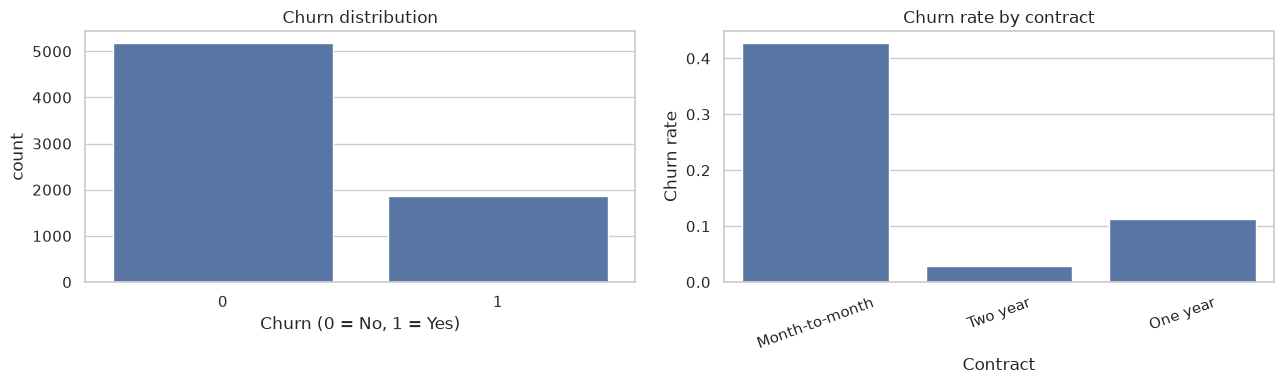

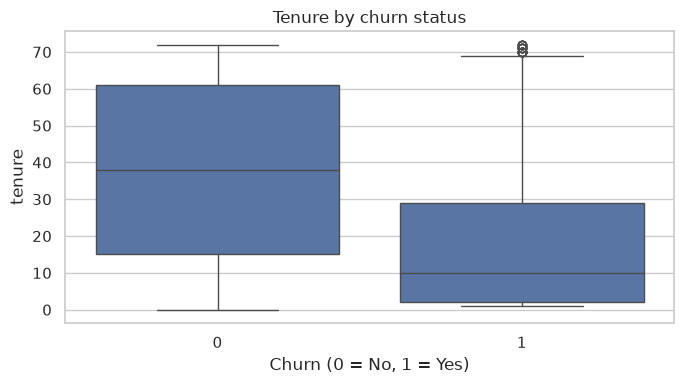

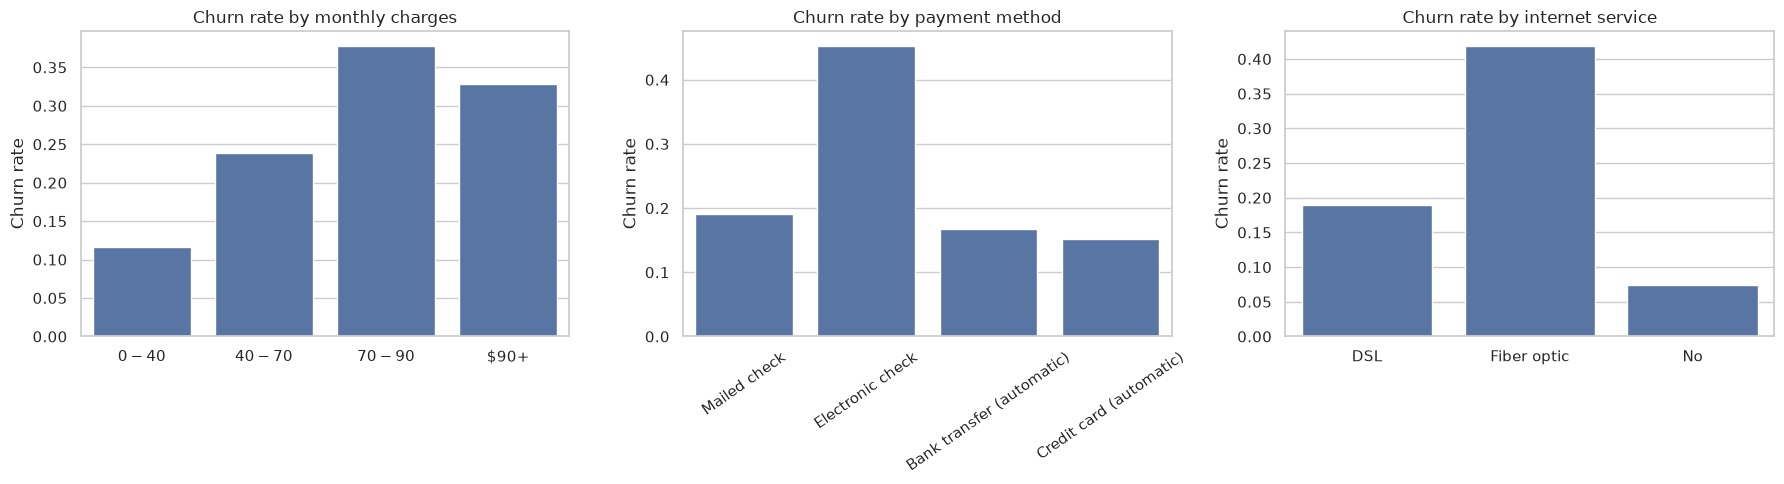

Business segment with highest churn rate: {'highest_charge_band': '$70-$90', 'highest_payment_method': 'Electronic check', 'highest_internet_service': 'Fiber optic'}


,Churn,Contract,tenure,MonthlyCharges,Payment Method,Internet Service
0,1,Month-to-month,2,53.85,Mailed check,DSL
1,1,Month-to-month,2,70.70,Electronic check,Fiber optic
2,1,Month-to-month,8,99.65,Electronic check,Fiber optic
3,1,Month-to-month,28,104.80,Electronic check,Fiber optic
4,1,Month-to-month,49,103.70,Bank transfer (automatic),Fiber optic


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="Churn", ax=axes[0])
axes[0].set_title("Churn distribution")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")

if "Contract" in df:
    sns.barplot(data=df, x="Contract", y="Churn", errorbar=None, ax=axes[1])
    axes[1].set_ylabel("Churn rate")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].set_title("Churn rate by contract")

plt.tight_layout()
fig.savefig(FIGURES / "eda.png", dpi=150)
display(fig)
plt.close(fig)

if "tenure" in df:
    fig = plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Churn", y="tenure")
    plt.title("Tenure by churn status")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.tight_layout()
    fig.savefig(FIGURES / "tenure_by_churn.png", dpi=150)
    display(fig)
    plt.close(fig)

# Business drivers: compare churn rates across actionable customer segments.
eda_df = df.copy()
eda_df["Monthly charge band"] = pd.cut(
    eda_df["MonthlyCharges"],
    bins=[0, 40, 70, 90, np.inf],
    labels=["$0-$40", "$40-$70", "$70-$90", "$90+"],
)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=eda_df, x="Monthly charge band", y="Churn", errorbar=None, ax=axes[0])
axes[0].set_title("Churn rate by monthly charges")
axes[0].set_ylabel("Churn rate")
axes[0].set_xlabel("")

sns.barplot(data=eda_df, x="Payment Method", y="Churn", errorbar=None, ax=axes[1])
axes[1].set_title("Churn rate by payment method")
axes[1].set_ylabel("Churn rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(data=eda_df, x="Internet Service", y="Churn", errorbar=None, ax=axes[2])
axes[2].set_title("Churn rate by internet service")
axes[2].set_ylabel("Churn rate")
axes[2].set_xlabel("")

plt.tight_layout()
fig.savefig(FIGURES / "business_churn_drivers.png", dpi=150)
display(fig)
plt.close(fig)

business_rates = {
    "highest_charge_band": eda_df.groupby("Monthly charge band", observed=False)["Churn"].mean().idxmax(),
    "highest_payment_method": df.groupby("Payment Method", observed=False)["Churn"].mean().idxmax(),
    "highest_internet_service": df.groupby("Internet Service", observed=False)["Churn"].mean().idxmax(),
}
print("Business segment with highest churn rate:", business_rates)
df[["Churn", "Contract", "tenure", "MonthlyCharges", "Payment Method", "Internet Service"]].head()

## 3) Train and compare models

We use a leakage-safe preprocessing pipeline with separate numeric and categorical steps, then compare class-weighted Logistic Regression and Random Forest models.

In [30]:
X, y = df.drop(columns="Churn"), df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric = X.select_dtypes(include=np.number).columns.tolist()
categorical = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
            ]),
            numeric,
        ),
        (
            "cat",
            Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("encode", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical,
        ),
    ]
)

estimators = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, class_weight="balanced", random_state=42, n_jobs=-1
    ),
}

fitted = {}
rows = []

for name, estimator in estimators.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
    })

    fitted[name] = (model, prob)
    print(f"\n{name}\n")
    print(classification_report(y_test, pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))

comparison = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
print("\nModel comparison:\n", comparison.round(3))
comparison.to_csv(OUT / "model_comparison.csv")


Logistic Regression

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Confusion matrix:
 [[754 281]
 [ 81 293]]

Random Forest

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

Confusion matrix:
 [[849 186]
 [126 248]]

Model comparison:
                      Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression     0.743      0.510   0.783     0.618    0.849


## 4) Select the best model and inspect feature importance

The overall best model is chosen by ROC-AUC, then we save that trained pipeline and inspect the strongest signals driving churn risk.

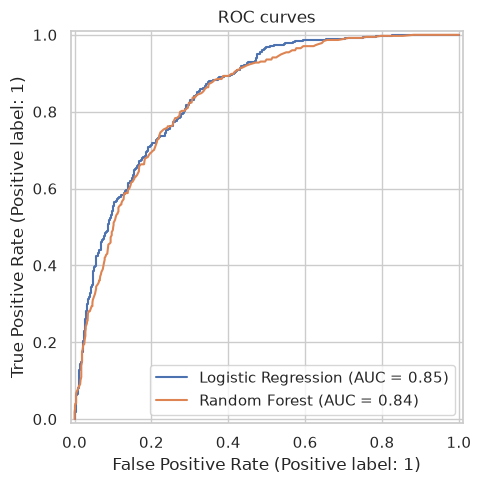

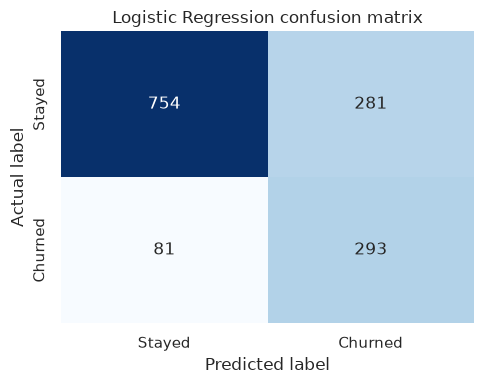

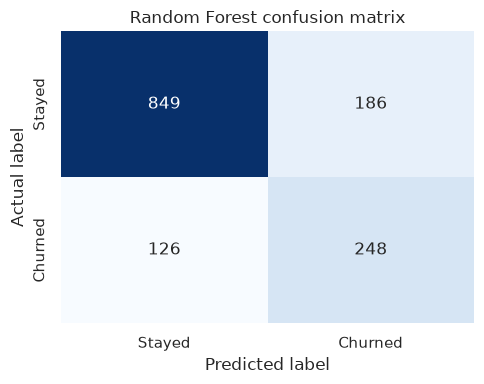


Best model by ROC-AUC: Logistic Regression

Most important features:
                               Feature  Importance  Absolute importance
0                         num__tenure   -1.191624             1.191624
11                cat__Dependents_Yes   -0.928777             0.928777
40             cat__Contract_Two year   -0.751826             0.751826
10                 cat__Dependents_No    0.701949             0.701949
38       cat__Contract_Month-to-month    0.656588             0.656588
18  cat__Internet Service_Fiber optic    0.585538             0.585538
17          cat__Internet Service_DSL   -0.557847             0.557847
1                 num__MonthlyCharges   -0.541526             0.541526
2                   num__TotalCharges    0.484630             0.484630
41          cat__Paperless Billing_No   -0.272578             0.272578


In [31]:
best_name = comparison.index[0]
best_model = fitted[best_name][0]
joblib.dump(best_model, OUT / "best_churn_model.joblib")

fig, ax = plt.subplots(figsize=(7, 5))
for name, (model, prob) in fitted.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.set_title("ROC curves")
plt.tight_layout()
fig.savefig(FIGURES / "roc_curves.png", dpi=150)
display(fig)
plt.close(fig)

for name, (model, prob) in fitted.items():
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"],
        ax=ax,
    )
    ax.set_title(f"{name} confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    plt.tight_layout()
    filename = name.lower().replace(" ", "_") + "_confusion_matrix.png"
    fig.savefig(FIGURES / filename, dpi=150)
    display(fig)
    plt.close(fig)

if best_name != "Logistic Regression":
    raise AssertionError(f"Expected Logistic Regression to be selected, got {best_name}")

names = best_model.named_steps["preprocessor"].get_feature_names_out()
estimator = best_model.named_steps["model"]
importance = pd.DataFrame({
    "Feature": names,
    "Importance": estimator.coef_[0],
    "Absolute importance": np.abs(estimator.coef_[0]),
}).sort_values("Absolute importance", ascending=False)
importance.head(20).to_csv(OUT / "feature_importance.csv", index=False)
print("\nBest model by ROC-AUC:", best_name)
print("\nMost important features:\n", importance.head(10))

## Business conclusion

Churn is concentrated among month-to-month customers and newer customers, with additional risk among customers paying higher monthly charges, using electronic checks, or subscribing to fiber-optic service. Retention efforts should prioritize early-tenure month-to-month customers in these segments with onboarding support, service-quality follow-up, and incentives for longer-term contracts or automatic payment methods.

The geography-free feature set keeps the model focused on customer behavior, services, and account characteristics rather than location. Model selection should continue to prioritize ROC-AUC alongside recall, because the business goal is to identify as many at-risk customers as practical without ignoring intervention cost.

The trained model and comparison outputs are saved in the `outputs/` directory for reuse.